# Half-Truth Ranking Vulnerability Analysis

This notebook analyzes the ranking metrics from the half-truth experiment.

**Key Questions:**
1. How often does the half-truth caption rank above the correct (short-truth) caption?
2. Which foil types cause the most ranking corruption?
3. How does CLIP handle partial vs. full truth in retrieval scenarios?

In [4]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tueplots import figsizes

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# For publication-quality figures
plt.rcParams.update(figsizes.icml2024_full())

# Output directory for plots
PLOT_DIR = Path('../plots/ht_rankings')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {PLOT_DIR.resolve()}")

Plots will be saved to: /mnt/lustre/work/oh/owl336/LabCLIP_v2/CLIP-not-BoW-unimodally/experiments/plots/ht_rankings


## Load Data

In [6]:
# Load ranking metrics
metrics_path = Path('../../ranking_results/ranking_metrics.json')

with open(metrics_path, 'r') as f:
    metrics = json.load(f)

# Convert to DataFrame for easier analysis
df = pd.DataFrame(metrics).T
df.index.name = 'condition'
df = df.reset_index()

# Add category column (component vs relation)
df['category'] = df['condition'].apply(
    lambda x: 'Component' if x.startswith('component') else 'Relation'
)

print(f"Loaded {len(df)} conditions")
df

Loaded 9 conditions


,condition,half_truth_intrusion_rate,half_truth_beats_full_rate,mean_rank_short_truth,mean_rank_full_truth,mean_rank_half_truth,mrr_short_truth,mrr_full_truth,mrr_half_truth,mean_displacement_vs_short,...,mean_margin_short_vs_half,mean_margin_full_vs_half,recall_at_1_short,recall_at_3_short,recall_at_5_short,recall_at_1_full,recall_at_3_full,n_samples,n_distractors,category
0,component_easy,0.584945,0.160429,3.017872,1.415896,2.689445,0.428934,0.838159,0.465015,0.584945,...,-0.008937,0.024509,0.126367,0.767662,0.925357,0.710050,0.982128,4756.0,10.0,Component
1,component_hard,0.724324,0.277477,3.085285,1.533333,2.209610,0.413166,0.789507,0.554181,0.724324,...,-0.022796,0.011375,0.124324,0.774775,0.933333,0.618018,0.978979,1665.0,10.0,Component
2,component_random,0.269854,0.088818,2.717343,1.351070,3.836967,0.470204,0.867333,0.349741,0.269854,...,0.011870,0.045011,0.128426,0.817964,0.936987,0.764353,0.983197,4999.0,10.0,Component
3,relation_swap,0.756557,0.297497,3.181381,1.554955,2.073874,0.412398,0.769063,0.575794,0.756557,...,-0.027041,0.006910,0.141141,0.736537,0.919720,0.573574,0.983383,4995.0,10.0,Relation
4,relation_antonym,0.786664,0.313359,3.193287,1.572877,2.025231,0.404359,0.768434,0.585093,0.786664,...,-0.027383,0.006604,0.128407,0.748592,0.923406,0.579410,0.979049,4439.0,10.0,Relation
5,relation_negation,0.795276,0.312060,3.222337,1.571695,1.991297,0.406829,0.768720,0.584063,0.795276,...,-0.029604,0.004239,0.141318,0.737257,0.920431,0.579569,0.978657,4826.0,10.0,Relation
6,object_wrong,0.618737,0.169191,3.044745,1.421813,2.566768,0.428318,0.830629,0.479005,0.618737,...,-0.012452,0.022480,0.133535,0.758564,0.922862,0.692146,0.981356,4291.0,10.0,Relation
7,subject_wrong,0.404564,0.109467,2.419981,1.405180,2.863398,0.521694,0.824617,0.423818,0.404564,...,0.009413,0.032625,0.209374,0.890225,0.977182,0.668517,0.989824,3243.0,10.0,Relation
8,attribute_wrong,0.740589,0.269678,3.033539,1.536619,2.151951,0.418970,0.787745,0.554872,0.740589,...,-0.024267,0.010494,0.131417,0.787817,0.941136,0.620123,0.978782,1461.0,10.0,Relation


## 1. Half-Truth Intrusion Rate by Condition

How often does the half-truth caption rank above the short-truth (correct) caption?

/tmp/ipykernel_495244/334463039.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


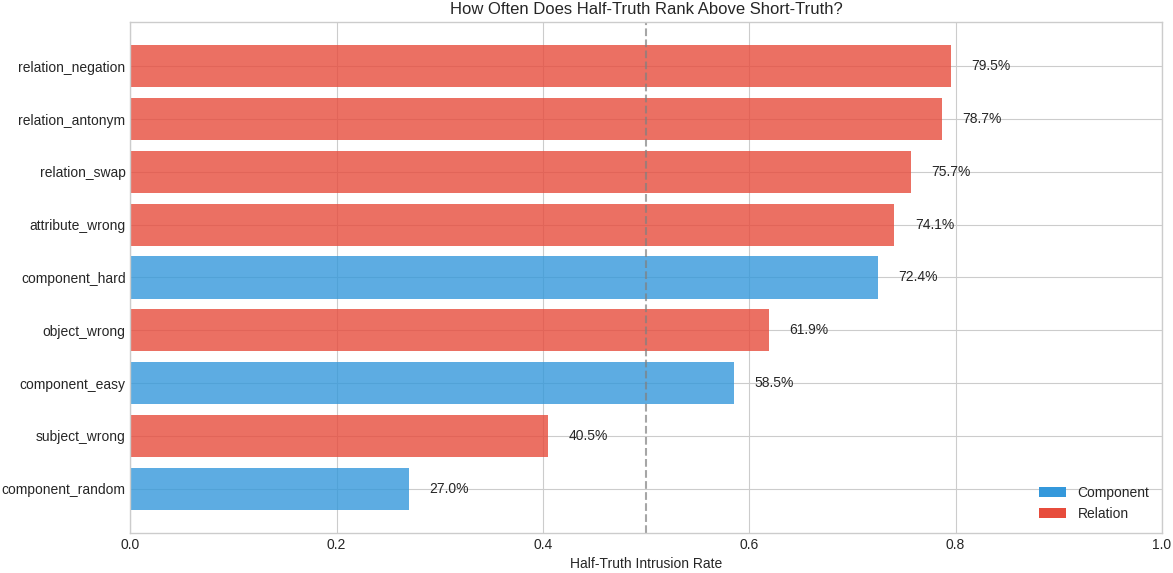

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

# Sort by intrusion rate
df_sorted = df.sort_values('half_truth_intrusion_rate', ascending=True)

# Color by category
colors = ['#3498db' if cat == 'Component' else '#e74c3c' for cat in df_sorted['category']]

bars = ax.barh(range(len(df_sorted)), df_sorted['half_truth_intrusion_rate'], color=colors, alpha=0.8)

ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted['condition'])
ax.set_xlabel('Half-Truth Intrusion Rate')
ax.set_title('How Often Does Half-Truth Rank Above Short-Truth?')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Random chance')
ax.set_xlim(0, 1)

# Add value labels
for i, (bar, rate) in enumerate(zip(bars, df_sorted['half_truth_intrusion_rate'])):
    ax.text(rate + 0.02, i, f'{rate:.1%}', va='center', fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Component'),
    Patch(facecolor='#e74c3c', label='Relation'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'intrusion_rate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Score Margins Analysis

The score margin shows the average difference between correct and half-truth scores.
- Positive margin = correct ranks higher
- Negative margin = half-truth ranks higher

/tmp/ipykernel_495244/4288841394.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


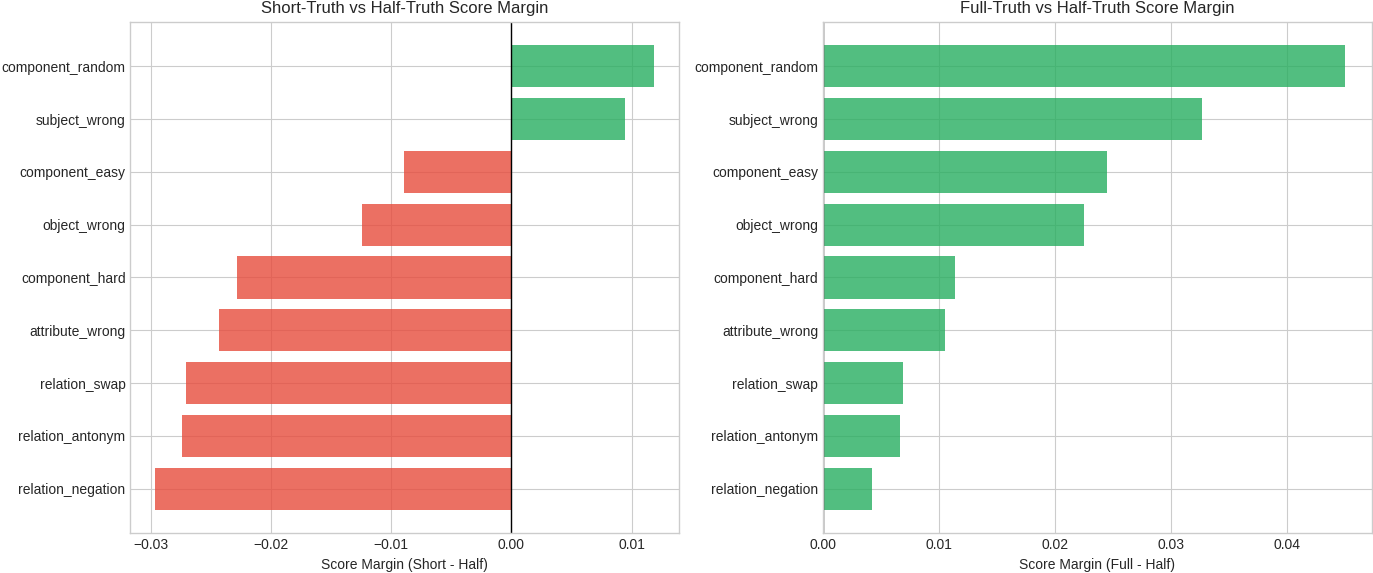

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Short-truth vs Half-truth margin
ax = axes[0]
df_sorted = df.sort_values('mean_margin_short_vs_half')
colors = ['#27ae60' if m > 0 else '#e74c3c' for m in df_sorted['mean_margin_short_vs_half']]
ax.barh(range(len(df_sorted)), df_sorted['mean_margin_short_vs_half'], color=colors, alpha=0.8)
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted['condition'])
ax.set_xlabel('Score Margin (Short - Half)')
ax.set_title('Short-Truth vs Half-Truth Score Margin')
ax.axvline(0, color='black', linewidth=1)

# Full-truth vs Half-truth margin
ax = axes[1]
df_sorted = df.sort_values('mean_margin_full_vs_half')
colors = ['#27ae60' if m > 0 else '#e74c3c' for m in df_sorted['mean_margin_full_vs_half']]
ax.barh(range(len(df_sorted)), df_sorted['mean_margin_full_vs_half'], color=colors, alpha=0.8)
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted['condition'])
ax.set_xlabel('Score Margin (Full - Half)')
ax.set_title('Full-Truth vs Half-Truth Score Margin')
ax.axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'score_margins.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. MRR Comparison: Short vs Full vs Half-Truth

/tmp/ipykernel_495244/2546438132.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


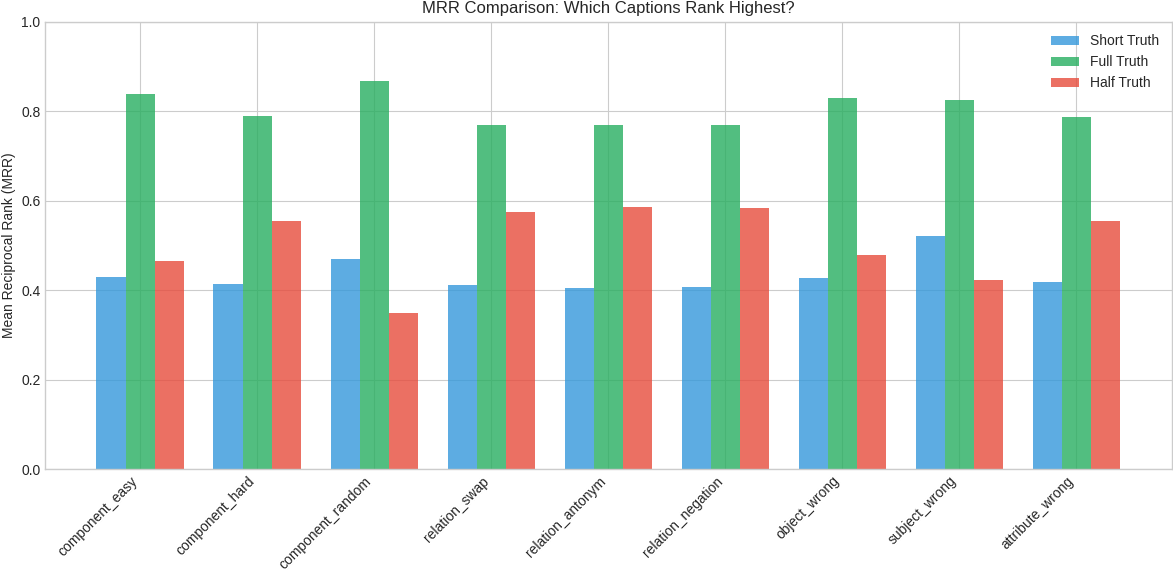

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df))
width = 0.25

ax.bar(x - width, df['mrr_short_truth'], width, label='Short Truth', color='#3498db', alpha=0.8)
ax.bar(x, df['mrr_full_truth'], width, label='Full Truth', color='#27ae60', alpha=0.8)
ax.bar(x + width, df['mrr_half_truth'], width, label='Half Truth', color='#e74c3c', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(df['condition'], rotation=45, ha='right')
ax.set_ylabel('Mean Reciprocal Rank (MRR)')
ax.set_title('MRR Comparison: Which Captions Rank Highest?')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'mrr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Displacement Analysis

How much does the correct answer's rank drop when half-truths are in the gallery?

/tmp/ipykernel_495244/1946402081.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


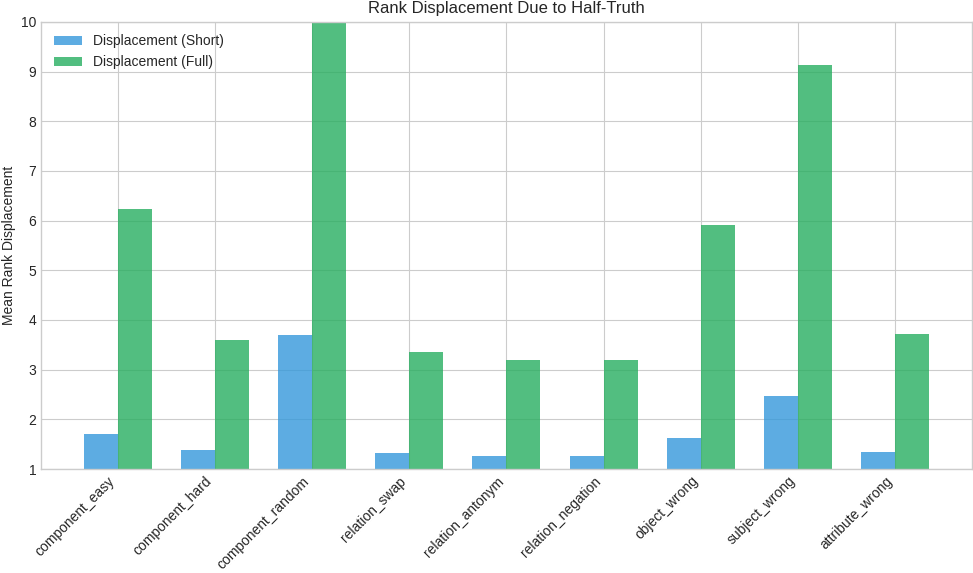

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df))
width = 0.35

ax.bar(x - width/2, 1/df['mean_displacement_vs_short'], width, 
       label='Displacement (Short)', color='#3498db', alpha=0.8)
ax.bar(x + width/2, 1/df['mean_displacement_vs_full'], width, 
       label='Displacement (Full)', color='#27ae60', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(df['condition'], rotation=45, ha='right')
ax.set_ylabel('Mean Rank Displacement')
ax.set_title('Rank Displacement Due to Half-Truth')
ax.legend()
ax.set_ylim(1,10)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'displacement_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Component vs Relation Summary

In [13]:
# Aggregate by category
category_summary = df.groupby('category').agg({
    'half_truth_intrusion_rate': ['mean', 'std'],
    'half_truth_beats_full_rate': ['mean', 'std'],
    'mean_margin_short_vs_half': ['mean', 'std'],
    'mrr_short_truth': ['mean', 'std'],
    'mrr_full_truth': ['mean', 'std'],
    'n_samples': 'sum',
}).round(4)

print("\n=== Summary by Category ===")
category_summary


=== Summary by Category ===


half_truth_intrusion_rate         half_truth_beats_full_rate  \
                               mean     std                       mean   
category                                                                 
Component                    0.5264  0.2328                     0.1756   
Relation                     0.6837  0.1508                     0.2452   

                  mean_margin_short_vs_half         mrr_short_truth          \
              std                      mean     std            mean     std   
category                                                                      
Component  0.0952                   -0.0066  0.0174          0.4374  0.0295   
Relation   0.0856                   -0.0186  0.0150          0.4321  0.0447   

          mrr_full_truth         n_samples  
                    mean     std       sum  
category                                    
Component         0.8317  0.0393   11420.0  
Relation          0.7915  0.0290   23255.0

/tmp/ipykernel_495244/434652626.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


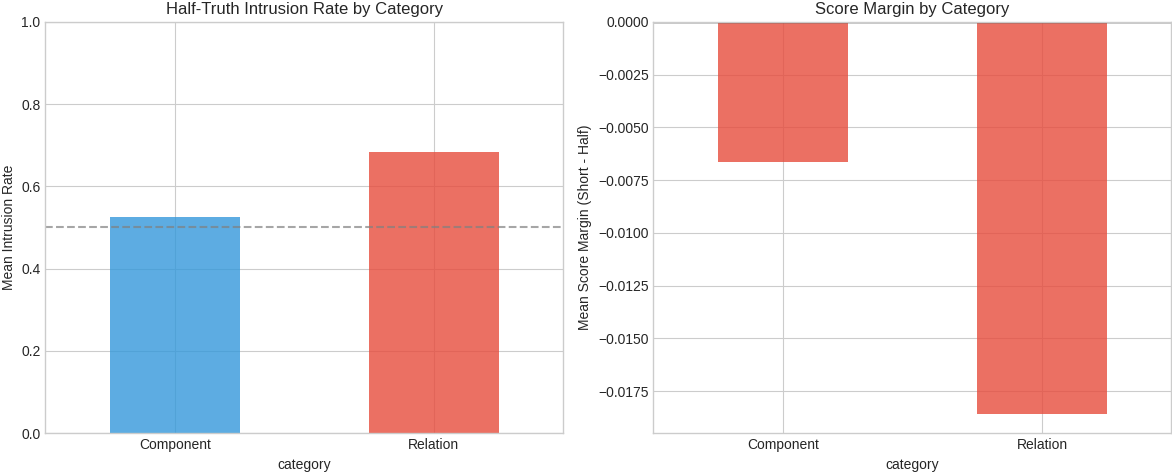

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Intrusion rate by category
ax = axes[0]
category_intrusion = df.groupby('category')['half_truth_intrusion_rate'].mean()
category_intrusion.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], alpha=0.8)
ax.set_ylabel('Mean Intrusion Rate')
ax.set_title('Half-Truth Intrusion Rate by Category')
ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.7)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Score margin by category
ax = axes[1]
category_margin = df.groupby('category')['mean_margin_short_vs_half'].mean()
colors = ['#27ae60' if m > 0 else '#e74c3c' for m in category_margin]
category_margin.plot(kind='bar', ax=ax, color=colors, alpha=0.8)
ax.set_ylabel('Mean Score Margin (Short - Half)')
ax.set_title('Score Margin by Category')
ax.axhline(0, color='black', linewidth=1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'category_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Recall@K Analysis

/tmp/ipykernel_495244/2313127541.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


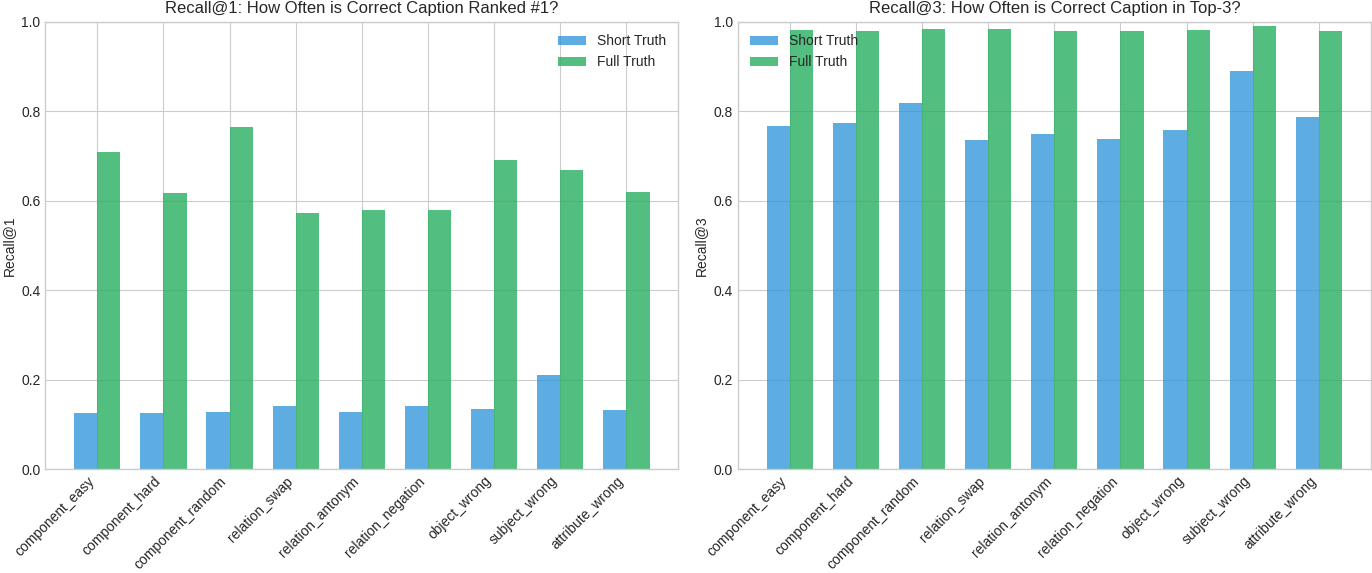

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Recall@1 comparison
ax = axes[0]
x = np.arange(len(df))
width = 0.35
ax.bar(x - width/2, df['recall_at_1_short'], width, label='Short Truth', color='#3498db', alpha=0.8)
ax.bar(x + width/2, df['recall_at_1_full'], width, label='Full Truth', color='#27ae60', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df['condition'], rotation=45, ha='right')
ax.set_ylabel('Recall@1')
ax.set_title('Recall@1: How Often is Correct Caption Ranked #1?')
ax.legend()
ax.set_ylim(0, 1)

# Recall@3 comparison
ax = axes[1]
ax.bar(x - width/2, df['recall_at_3_short'], width, label='Short Truth', color='#3498db', alpha=0.8)
ax.bar(x + width/2, df['recall_at_3_full'], width, label='Full Truth', color='#27ae60', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df['condition'], rotation=45, ha='right')
ax.set_ylabel('Recall@3')
ax.set_title('Recall@3: How Often is Correct Caption in Top-3?')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'recall_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Heatmap of All Metrics

RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

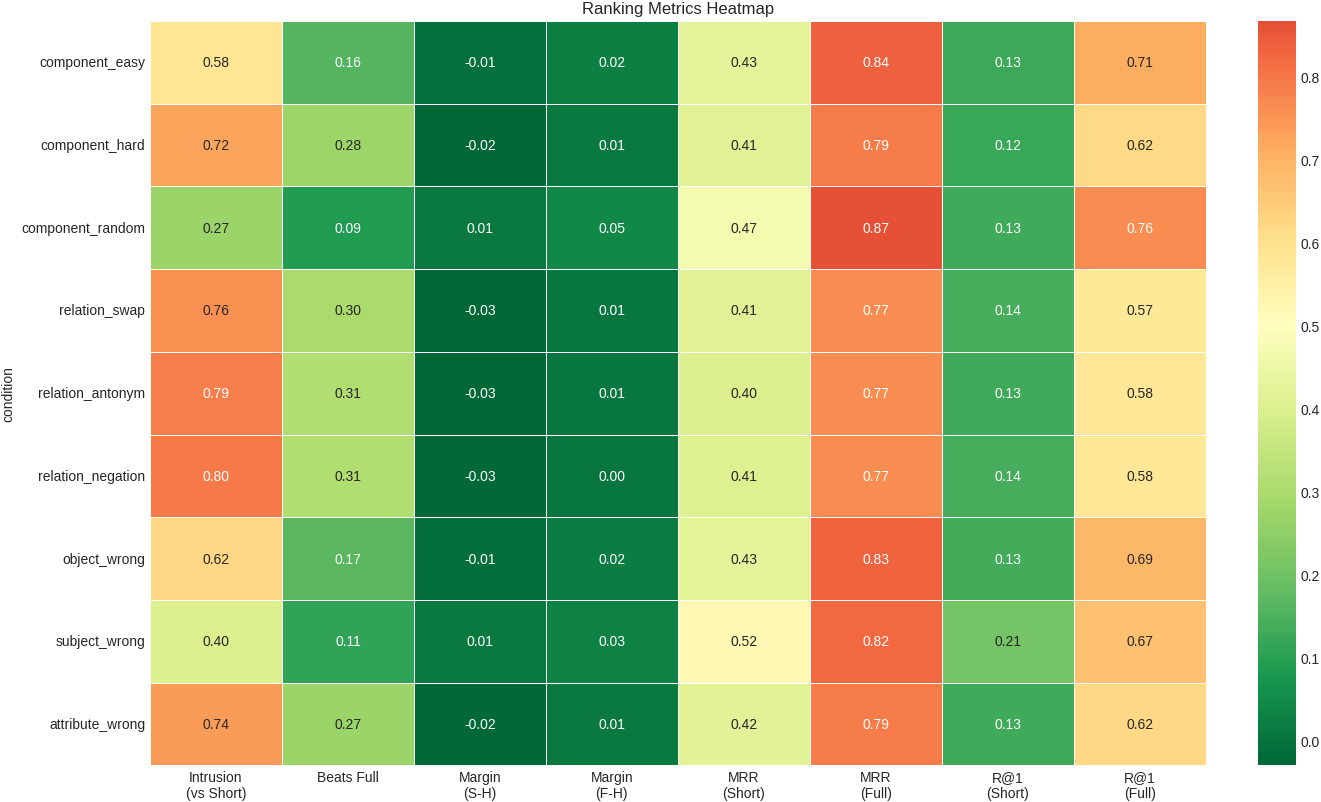

In [16]:
# Select key metrics for heatmap
heatmap_cols = [
    'half_truth_intrusion_rate',
    'half_truth_beats_full_rate', 
    'mean_margin_short_vs_half',
    'mean_margin_full_vs_half',
    'mrr_short_truth',
    'mrr_full_truth',
    'recall_at_1_short',
    'recall_at_1_full',
]

heatmap_data = df.set_index('condition')[heatmap_cols]

# Rename columns for display
heatmap_data.columns = [
    'Intrusion\n(vs Short)',
    'Beats Full',
    'Margin\n(S-H)',
    'Margin\n(F-H)',
    'MRR\n(Short)',
    'MRR\n(Full)',
    'R@1\n(Short)',
    'R@1\n(Full)',
]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            center=0.5, ax=ax, linewidths=0.5)
ax.set_title('Ranking Metrics Heatmap')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Key Findings Summary

In [ ]:
print("=" * 70)
print("KEY FINDINGS: Half-Truth Ranking Vulnerability")
print("=" * 70)

total_samples = df['n_samples'].sum()
weighted_intrusion = (df['half_truth_intrusion_rate'] * df['n_samples']).sum() / total_samples

print(f"\n📊 Overall Statistics:")
print(f"   Total samples evaluated: {total_samples:,}")
print(f"   Weighted avg intrusion rate: {weighted_intrusion:.1%}")

# Most vulnerable conditions
print(f"\n🚨 Most Vulnerable Conditions (Intrusion Rate):")
top_vulnerable = df.nlargest(3, 'half_truth_intrusion_rate')[['condition', 'half_truth_intrusion_rate']]
for _, row in top_vulnerable.iterrows():
    print(f"   • {row['condition']}: {row['half_truth_intrusion_rate']:.1%}")

# Least vulnerable conditions
print(f"\n✅ Least Vulnerable Conditions (Intrusion Rate):")
least_vulnerable = df.nsmallest(3, 'half_truth_intrusion_rate')[['condition', 'half_truth_intrusion_rate']]
for _, row in least_vulnerable.iterrows():
    print(f"   • {row['condition']}: {row['half_truth_intrusion_rate']:.1%}")

# Category comparison
print(f"\n📈 Category Comparison:")
for cat in ['Component', 'Relation']:
    cat_df = df[df['category'] == cat]
    cat_intrusion = (cat_df['half_truth_intrusion_rate'] * cat_df['n_samples']).sum() / cat_df['n_samples'].sum()
    print(f"   {cat}: {cat_intrusion:.1%} intrusion rate")

# Key insight
print(f"\n💡 Key Insight:")
if weighted_intrusion > 0.5:
    print(f"   CLIP is vulnerable to half-truths! In {weighted_intrusion:.1%} of cases,")
    print(f"   a half-truth caption (correct + wrong addition) ranks above the correct short caption.")
else:
    print(f"   CLIP shows some robustness to half-truths, with only {weighted_intrusion:.1%}")
    print(f"   of cases having half-truth rank above correct.")

print("\n" + "=" * 70)

In [ ]:
# Save summary to file
summary = {
    'total_samples': int(total_samples),
    'weighted_intrusion_rate': weighted_intrusion,
    'most_vulnerable': top_vulnerable.to_dict('records'),
    'least_vulnerable': least_vulnerable.to_dict('records'),
    'category_intrusion': {
        cat: float((df[df['category'] == cat]['half_truth_intrusion_rate'] * 
                   df[df['category'] == cat]['n_samples']).sum() / 
                  df[df['category'] == cat]['n_samples'].sum())
        for cat in ['Component', 'Relation']
    }
}

with open(PLOT_DIR / 'analysis_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Summary saved to {PLOT_DIR / 'analysis_summary.json'}")